In [103]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


In [104]:
df_data = pd.read_csv('data/raw/skill_builder_data.csv', encoding='ISO-8859-1', low_memory=False)
df_data.head()


,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,answer_type,sequence_id,student_class_id,position,type,base_sequence_id,skill_id,skill_name,teacher_id,school_id,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original
0,33022537,277618,64525,33139,51424,1,1,1,32454,tutor,algebra,5948,13241,126,MasterySection,5948,1.0,Box and Whisker,22763,73,0,3,32454,30799,NaN,26,0,NaN,1,1.0
1,33022709,277618,64525,33150,51435,1,1,1,4922,tutor,algebra,5948,13241,126,MasterySection,5948,1.0,Box and Whisker,22763,73,0,3,4922,30799,NaN,55,0,NaN,2,2.0
2,35450204,220674,70363,33159,51444,1,0,2,25390,tutor,algebra,5948,11816,22,MasterySection,5948,1.0,Box and Whisker,22763,73,0,3,42000,30799,NaN,88,0,NaN,1,1.0
3,35450295,220674,70363,33110,51395,1,1,1,4859,tutor,algebra,5948,11816,22,MasterySection,5948,1.0,Box and Whisker,22763,73,0,3,4859,30059,NaN,41,0,NaN,2,2.0
4,35450311,220674,70363,33196,51481,1,0,14,19813,tutor,algebra,5948,11816,22,MasterySection,5948,1.0,Box and Whisker,22763,73,3,4,124564,30060,NaN,65,0,0.0,3,3.0


In [105]:
columns_to_keep = ['order_id', 'user_id', 'correct', 'skill_id', 'skill_name', 'problem_id',
                              'ms_first_response', 'bottom_hint', 'opportunity']
df_data_filtered = df_data[columns_to_keep]
df_data_filtered.isna().sum()


order_id                  0
user_id                   0
correct                   0
skill_id              66326
skill_name            78690
problem_id                0
ms_first_response         0
bottom_hint          445627
opportunity               0
dtype: int64

In [106]:
df_data_full = df_data_filtered.dropna(subset='skill_id')

df_data_full = df_data_full.copy()

df_data_full['bottom_hint'] = df_data_full['bottom_hint'].fillna(0)

df_data_full['opportunity_padded'] = df_data_full['opportunity'].apply(lambda x: f"{int(x):04d}")

# Create the 'timestamp' column by concatenating 'order_id' and padded 'opportunity'
df_data_full['timestamp'] = df_data_full['order_id'].astype(str) + df_data_full['opportunity_padded']

df_data_full.drop(columns=['opportunity', 'opportunity_padded', 'order_id'], inplace=True)

df_data_full.head()


,user_id,correct,skill_id,skill_name,problem_id,ms_first_response,bottom_hint,timestamp
0,64525,1,1.0,Box and Whisker,51424,32454,0.0,330225370001
1,64525,1,1.0,Box and Whisker,51435,4922,0.0,330227090002
2,70363,0,1.0,Box and Whisker,51444,25390,0.0,354502040001
3,70363,1,1.0,Box and Whisker,51395,4859,0.0,354502950002
4,70363,0,1.0,Box and Whisker,51481,19813,0.0,354503110003


In [107]:
df_data_full.dtypes

user_id                int64
correct                int64
skill_id             float64
skill_name            object
problem_id             int64
ms_first_response      int64
bottom_hint          float64
timestamp             object
dtype: object

There are no trailing zeros in the ID columns, so we convert them to int.

In [108]:
df_data_full['skill_id'] = pd.to_numeric(df_data_full['skill_id'], errors='coerce').astype('Int64')
columns_to_int = ['user_id', 'correct', 'skill_id', 'problem_id', 'ms_first_response', 'bottom_hint']
df_data_full[columns_to_int] = df_data_full[columns_to_int].astype(int)

# Convert specific columns to string
columns_to_str = ['skill_name', 'timestamp']  # Replace with your column names
df_data_full[columns_to_str] = df_data_full[columns_to_str].astype(str)

df_data_sorted = df_data_full.sort_values(by=['user_id', 'timestamp'])
df_data_sorted.head()


,user_id,correct,skill_id,skill_name,problem_id,ms_first_response,bottom_hint,timestamp
3957,14,0,2,Circle Graph,93383,26271,1,216176230001
94047,14,0,37,nan,93383,26271,1,216176230001
172411,14,0,70,Percent Of,93383,26271,1,216176230001
3958,14,1,2,Circle Graph,93407,29123,0,216176320002
94048,14,1,37,nan,93407,29123,0,216176320002


In [109]:
# Group by 'user_id' and 'timestamp' and count the unique 'problem_id' values for each group
unique_problem_ids_count = df_data_sorted.groupby(['user_id', 'timestamp'])['problem_id'].nunique().reset_index(name='unique_problem_id_count')

# Display the result
unique_problem_ids_count['unique_problem_id_count'].unique()


array([1], dtype=int64)

The check above means that correctly to one user-timestamp pair only one problem ID belongs.
IMPORTANT: An answer can appear multiple times if it belongs to multiple skills. We wan this be consistent, so the same answer ID should be present for all its skill IDs every time. Because of this, we break our data into 2 parts: user-answer and answer-skill sets.

In [110]:
df_skill_problem_mapping = df_data_sorted[['skill_id', 'skill_name', 'problem_id']].drop_duplicates().sort_values(by='skill_id').reset_index(drop=True)
df_answers = df_data_sorted.drop(columns=['skill_id', 'skill_name']).drop_duplicates().reset_index(drop=True)
df_answers = df_answers.merge(df_skill_problem_mapping, on='problem_id')

cols = df_answers.columns.tolist()
cols[-1], cols[1] = cols[1], cols[-1]  # Swap second and last column positions
df_answers = df_answers[cols]  # Reorder the DataFrame with the new column order

# Step 2: Shuffle the DataFrame
df_answers = df_answers.sample(frac=1, random_state=42).reset_index(drop=True)

# Step 3: Order the DataFrame by 'user_id' and 'timestamp'
df_answers = df_answers.sort_values(by=['user_id', 'timestamp']).reset_index(drop=True)

# Display the modified DataFrame
df_answers.head(20)


,user_id,skill_name,problem_id,ms_first_response,bottom_hint,timestamp,skill_id,correct
0,14,Percent Of,93383,26271,1,216176230001,70,0
1,14,Circle Graph,93383,26271,1,216176230001,2,0
2,14,nan,93383,26271,1,216176230001,37,0
3,14,nan,93407,29123,0,216176320002,37,1
4,14,Circle Graph,93407,29123,0,216176320002,2,1
5,14,Percent Of,93407,29123,0,216176320002,70,1
6,14,nan,93400,13779,1,216176410003,37,0
7,14,Circle Graph,93400,13779,1,216176410003,2,0
8,14,Percent Of,93400,13779,1,216176410003,70,0
9,14,Percent Of,93419,16901,1,216176500004,70,0


Another problem is that we want one answer to appear only once, even multiple skill IDs belong to it. Because of this reason, we break the skill ID column into multiple binary columns.

In [111]:
# Create a binary column for each skill_id
columns_to_keep = ["user_id", "timestamp", "problem_id", "ms_first_response", "bottom_hint", "correct"]

df_answers_pivot = df_answers.pivot_table(
    index=columns_to_keep,
    columns="skill_id",
    aggfunc="size",
    fill_value=0
).reset_index()

# Flatten the column names
df_answers_pivot.columns.name = None
df_answers_pivot = df_answers_pivot.rename_axis(None, axis=1)
# Sort
df_answers_pivot = df_answers_pivot.sort_values(by=['user_id', 'timestamp'])
# Display the resulting DataFrame
df_answers_pivot.head()


,user_id,timestamp,problem_id,ms_first_response,bottom_hint,correct,1,2,4,5,8,9,10,11,12,13,14,15,16,17,18,21,22,24,25,26,27,32,34,35,37,39,40,42,43,46,47,48,49,50,51,53,54,58,61,63,64,65,67,69,70,74,75,76,77,79,80,81,82,83,84,85,86,91,92,94,96,97,99,101,102,104,105,110,163,165,166,173,190,193,203,204,217,221,276,277,278,279,280,290,292,293,294,295,296,297,298,299,301,303,307,308,309,310,311,312,314,317,321,322,323,324,325,331,333,334,340,343,346,348,350,356,362,365,367,368,371,375,378
0,14,216176230001,93383,26271,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,14,216176320002,93407,29123,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,14,216176410003,93400,13779,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,14,216176500004,93419,16901,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,14,216176590005,93420,11079,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


We only want to keep user who answered at least and at most a certain amount of different problems and skills for which at least a certain amount of people gave answers, and one of them at least a certain amount of times.

In [112]:
max_user_sequence_len = 400
min_user_sequence_len = 5

min_user_per_skill = 10
min_len_longest_seq = 3


## Valid users

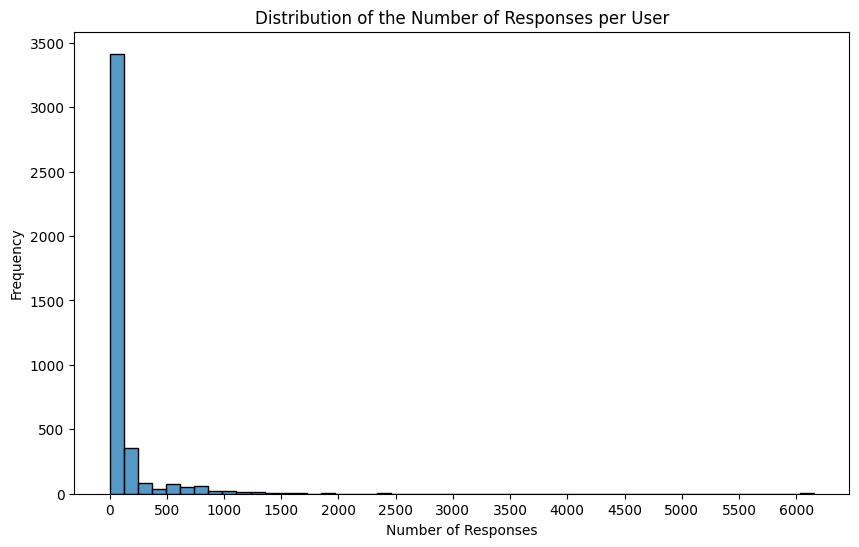

In [113]:
user_counts = df_answers_pivot['user_id'].value_counts()

plt.figure(figsize=(10, 6))
sns.histplot(user_counts, bins=50, kde=False)
plt.title('Distribution of the Number of Responses per User')
plt.xlabel('Number of Responses')
plt.ylabel('Frequency')
plt.xticks(range(0, max(user_counts), 500))  # Adjust range and step as needed

plt.show()


In [114]:
len_before = len(df_answers_pivot)

df_filtered_user = df_answers_pivot.groupby('user_id').filter(lambda x: len(x) >= min_user_sequence_len)

# Then, for each user_id, keep only the first max_user_sequence_len rows
df_answers_valid_user = df_filtered_user.groupby('user_id').head(max_user_sequence_len)

# Display the filtered DataFrame
len_after = len(df_answers_valid_user)
diff = len_before - len_after

print(f"{len_after} rows kept out for {len_before}, meaning that {diff} rows were dropped.")


301333 rows kept out for 442916, meaning that 141583 rows were dropped.


## Valid skills

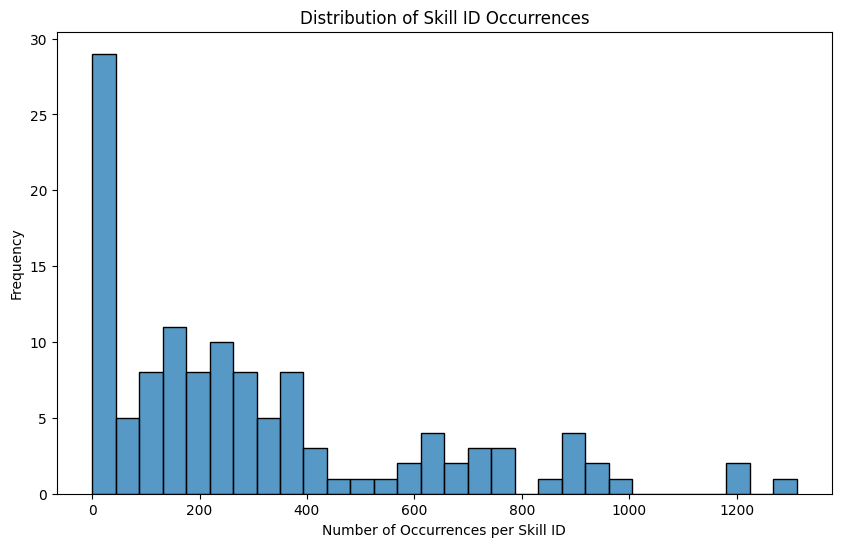

In [115]:
# Step 1: Count occurrences for each skill ID (sum the binary columns)
num_non_skill_columns = len(columns_to_keep)
skill_occurrences = df_answers_valid_user.groupby('user_id').max().iloc[:, num_non_skill_columns-1:].sum()

# Step 2: Plot a histogram of occurrences per skill
plt.figure(figsize=(10, 6))
sns.histplot(skill_occurrences, bins=30, kde=False)  # Adjust bins as needed
plt.title('Distribution of Skill ID Occurrences')
plt.xlabel('Number of Occurrences per Skill ID')
plt.ylabel('Frequency')
plt.show()


Closer look

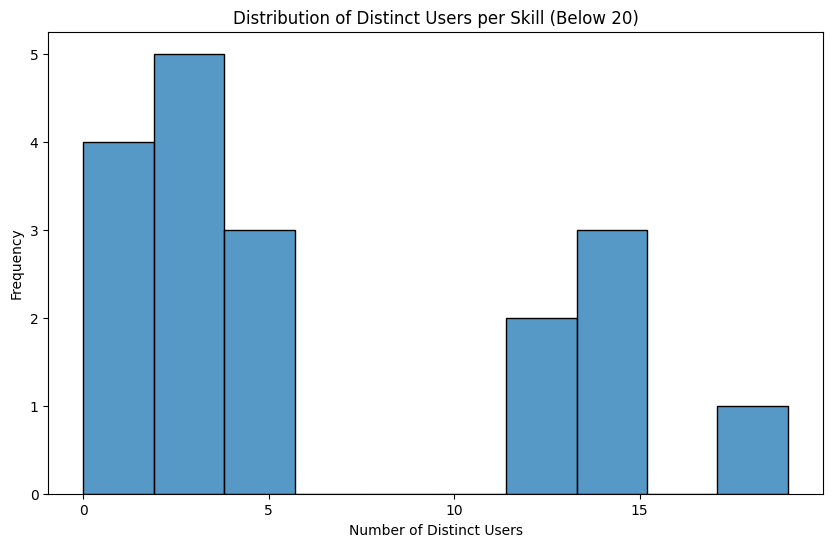

In [116]:
max_threshold = 20

skill_occurrences_below_th = skill_occurrences[skill_occurrences < max_threshold]
plt.figure(figsize=(10, 6))
sns.histplot(skill_occurrences_below_th, bins=10, kde=False)
plt.title(f'Distribution of Distinct Users per Skill (Below {max_threshold})')
plt.xlabel('Number of Distinct Users')
plt.ylabel('Frequency')
plt.xticks(range(0, max(skill_occurrences_below_th), 5))  # Adjust range and step as needed

plt.show()

In [117]:
len_before = len(df_answers_valid_user)

# Step 1: Identify skill_ids with less than 10 unique users
skills_to_remove = skill_occurrences[skill_occurrences < min_user_per_skill].index

# Step 2: Remove these skill_ids from the DataFrame
df_answers_valid_skills = df_answers_valid_user[[col for col in df_answers_valid_user.columns if col not in skills_to_remove]]
# Keep only rows where the sum of skill columns is not 0
df_answers_valid_skills = df_answers_valid_skills[df_answers_valid_skills.iloc[:, num_non_skill_columns:].sum(axis=1) != 0]

# Confirm the change by checking the number of unique skill_ids left
# Display the filtered DataFrame
len_after = len(df_answers_valid_skills)
diff = len_before - len_after

print(f"{len_after} rows kept out for {len_before}, meaning that {diff} rows were dropped.")


301120 rows kept out for 301333, meaning that 213 rows were dropped.


For each skill we need at least one sequence, which has a length of at least a given value.

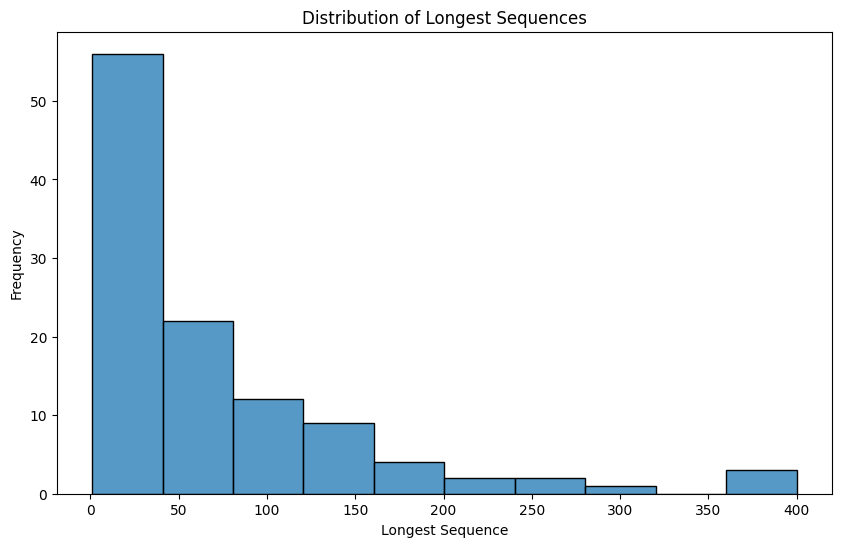

In [118]:
# Step 1: Count how many times each user_id appears for each skill_id
user_skill_counts = df_answers_valid_skills.groupby('user_id').sum()

# Step 2: Find the maximum user_count for each skill_id
max_skill_counts = user_skill_counts.iloc[:, num_non_skill_columns-1:].max()

plt.figure(figsize=(10, 6))
sns.histplot(max_skill_counts, bins=10, kde=False)
plt.title('Distribution of Longest Sequences')
plt.xlabel('Longest Sequence')
plt.ylabel('Frequency')

plt.show()

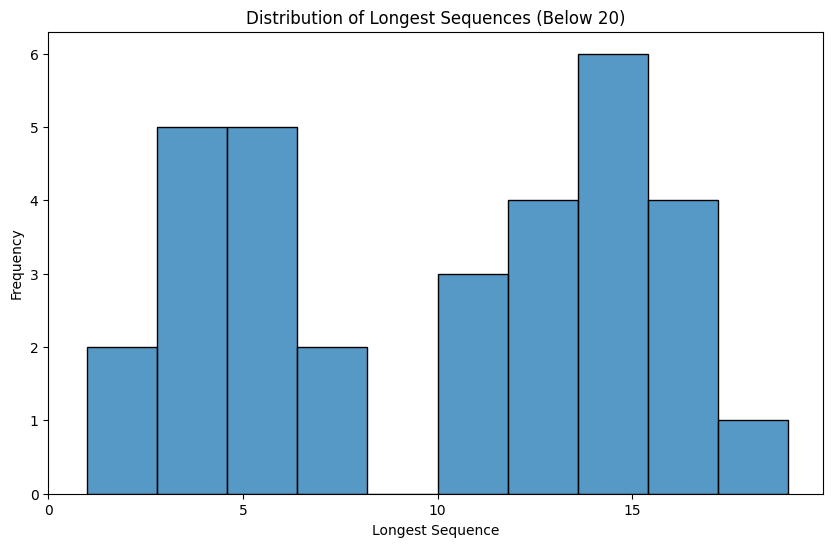

In [119]:
max_threshold = 20

max_skill_counts_below_th = max_skill_counts[max_skill_counts < max_threshold]
plt.figure(figsize=(10, 6))
sns.histplot(max_skill_counts_below_th, bins=10, kde=False)
plt.title(f'Distribution of Longest Sequences (Below {max_threshold})')
plt.xlabel('Longest Sequence')
plt.ylabel('Frequency')
plt.xticks(range(0, max(max_skill_counts_below_th), 5))  # Adjust range and step as needed

plt.show()

In [120]:
len_before = len(df_answers_valid_user)

# Step 1: Identify skill_ids with less than 10 unique users
skills_to_remove = max_skill_counts[max_skill_counts < min_len_longest_seq].index

# Step 2: Remove these skill_ids from the DataFrame
df_answers_valid_skills = df_answers_valid_skills[[col for col in df_answers_valid_skills.columns if col not in skills_to_remove]]
# Keep only rows where the sum of skill columns is not 0
df_answers_valid_skills = df_answers_valid_skills[df_answers_valid_skills.iloc[:, num_non_skill_columns:].sum(axis=1) != 0]

# Confirm the change by checking the number of unique skill_ids left
# Display the filtered DataFrame
len_after = len(df_answers_valid_skills)
diff = len_before - len_after

print(f"{len_after} rows kept out for {len_before}, meaning that {diff} rows were dropped.")

301088 rows kept out for 301333, meaning that 245 rows were dropped.


We have to check if a later filtering corrupted an earlier condition, hence we pack the filterings inside a function and do it until it does not have any effects.

In [125]:
user_counts = df_answers_valid_skills['user_id'].value_counts()
print(f"The minimum #appearances of user: {user_counts.min()}")
print(f"The maximum #appearances of user: {user_counts.max()}")

skill_occurrences = df_answers_valid_skills.groupby('user_id').max().iloc[:, num_non_skill_columns-1:].sum()  # Assuming binary skill columns start from 3rd column onward
print(f"The minimum #appearances amongst the skills: {skill_occurrences.min()}")

user_skill_counts = df_answers_valid_skills.groupby('user_id').sum()
max_skill_counts = user_skill_counts.iloc[:, num_non_skill_columns-1:].max()
print(f"The minimum longest sequence length amongst the skills: {max_skill_counts.min()}")


The minimum #appearances of user: 3
The maximum #appearances of user: 400
The minimum #appearances amongst the skills: 13
The minimum longest sequence length amongst the skills: 3


The minimal number of a user appearance decreased to 3, but it is still something we can work with, hence we do not perform any further cleaning steps.

## Final values

In [122]:
num_users = len(df_answers_valid_skills['user_id'].unique())
num_skills = len(df_answers_valid_skills.columns) - num_non_skill_columns
num_answers = len(df_answers_valid_skills)
print(f'Number of users: {num_users}')
print(f'Number of skills: {num_skills}')
print(f'Number of answers: {num_answers}')


Number of users: 3657
Number of skills: 109
Number of answers: 301088


In [123]:
df_answers_valid_skills.head()

,user_id,timestamp,problem_id,ms_first_response,bottom_hint,correct,1,2,4,5,8,9,10,11,12,13,14,15,16,17,18,21,22,24,25,26,27,32,34,35,37,39,40,42,46,47,48,49,50,51,53,54,58,61,63,64,65,67,69,70,74,75,76,77,79,80,81,82,83,84,85,86,91,92,94,96,97,99,101,104,105,110,163,165,166,173,190,193,203,204,217,221,276,277,278,279,280,290,292,293,294,295,296,297,298,299,301,303,307,308,309,310,311,312,317,321,322,323,325,346,350,367,368,375,378
0,14,216176230001,93383,26271,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,14,216176320002,93407,29123,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,14,216176410003,93400,13779,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,14,216176500004,93419,16901,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,14,216176590005,93420,11079,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Original values

In [124]:
num_users_og = len(df_data['user_id'].unique())
num_skills_og = len(df_data['skill_id'].unique())
num_answers_og = len(df_data)
print(f'Number of original users: {num_users_og}')
print(f'Number of original skills: {num_skills_og}')
print(f'Number of original answers: {num_answers_og}')

Number of original users: 4217
Number of original skills: 124
Number of original answers: 525534


We automatize these cleaning steps in the `src/data_preprocessing.py` script.